# Word-level VAD ground truth for GoEmotions comment embeddings

This notebook builds a new comment-level ground truth by:

1. Loading the comment embeddings and metadata from `goemotions_embed_pipeline.py`.
2. Loading `brm-emot-submit.csv`, treating it as a word-level VAD lexicon.
3. Tokenizing each comment, assigning VAD to matched words, and averaging the matched word VAD vectors.
4. Sampling up to `50` comments per GoEmotions label to keep the pairwise step cheap.
5. Comparing pairwise word-VAD distances against pairwise embedding/manifold distances.

Tiny methodological complaint, because apparently reality insists: raw VAD cosine similarity can be misleading because VAD values are usually all positive on a 1-9 scale. This notebook therefore computes:
- raw VAD cosine distance,
- centered VAD cosine distance, subtracting midpoint `5`,
- Euclidean VAD distance.

The centered cosine version is usually more interpretable than raw cosine.

In [15]:
# If needed, run this in your VSCode notebook terminal:
# pip install numpy pandas scipy scikit-learn matplotlib

from pathlib import Path
import re
import math
import warnings

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import pearsonr, spearmanr, kendalltau

from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

## 1. Configure paths

Edit these if your project layout differs. The defaults match the earlier pipeline convention:
`D:/pyprojects/m4r/data/goemotions/manifold_outputs/metadata.csv` and `embeddings.npy`.

In [16]:
PROJECT_DIR = Path(r"D:/pyprojects/m4r")
DATA_DIR = PROJECT_DIR / "data" / "goemotions"

MANIFOLD_DIR = DATA_DIR / "manifold_outputs"
METADATA_PATH = MANIFOLD_DIR / "metadata.csv"
EMBEDDINGS_PATH = MANIFOLD_DIR / "embeddings.npy"

# Put brm-emot-submit.csv here, or change this path.
BRM_PATH = DATA_DIR / "brm-emot-submit.csv"

OUT_DIR = PROJECT_DIR / "new_plots" / "word_vad_ground_truth"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_PER_LABEL = 50
MIN_MATCHED_WORDS = 1          # Raise to 2 or 3 if too many comments rely on one lexicon hit.
RUN_KNN_GEODESIC = True        # Set False for a faster first smoke test.
KNN_K = "auto"                 # "auto" finds the smallest connected k, or use an int like 10.
KNN_K_MAX = 50
GEODESIC_PCA_DIMS = 50         # PCA before KNN geodesic for speed/stability. Set 0 to use raw embeddings.
MAX_SCATTER_PAIRS = 60000      # Plotting cap only; correlations use all valid pairs.

print("Metadata:", METADATA_PATH)
print("Embeddings:", EMBEDDINGS_PATH)
print("BRM lexicon:", BRM_PATH)
print("Output:", OUT_DIR)

Metadata: D:\pyprojects\m4r\data\goemotions\manifold_outputs\metadata.csv
Embeddings: D:\pyprojects\m4r\data\goemotions\manifold_outputs\embeddings.npy
BRM lexicon: D:\pyprojects\m4r\data\goemotions\brm-emot-submit.csv
Output: D:\pyprojects\m4r\new_plots\word_vad_ground_truth


## 2. Load embeddings and metadata

In [17]:
metadata = pd.read_csv(METADATA_PATH)
X = np.load(EMBEDDINGS_PATH)

if len(metadata) != len(X):
    raise ValueError(f"metadata rows ({len(metadata)}) != embedding rows ({len(X)}). Something is misaligned. Humanity survives another preventable bug.")

required_meta_cols = {"text", "label_name"}
missing = required_meta_cols - set(metadata.columns)
if missing:
    raise ValueError(f"metadata.csv is missing required columns: {sorted(missing)}")

metadata = metadata.reset_index(drop=True)
metadata["_embedding_row"] = np.arange(len(metadata))

print("Embeddings shape:", X.shape)
print("Metadata shape:", metadata.shape)
display(metadata.head())
display(metadata["label_name"].value_counts().sort_index().to_frame("available"))

Embeddings shape: (4997, 3072)
Metadata shape: (4997, 6)


,original_row,text,label_idx,label_name,embedding_text,_embedding_row
0,6630,Your idea of what a nice entre or nice wine co...,0,admiration,Your idea of what a nice entre or nice wine co...,0
1,24661,I am so relieved,23,relief,I am so relieved,1
2,38794,A reason to play the game every 3 month?,7,curiosity,A reason to play the game every 3 month?,2
3,29718,Lakers truly have the worst fans,3,annoyance,Lakers truly have the worst fans,3
4,2871,Great way to clarify! That's the whole point o...,4,approval,Great way to clarify! That's the whole point o...,4


,available
label_name,
admiration,201
amusement,201
anger,201
annoyance,201
approval,201
caring,201
confusion,201
curiosity,201
desire,201


## 3. Load BRM word-level VAD lexicon

This parser tries to tolerate common column names such as `Word`, `V.Mean.Sum`, `A.Mean.Sum`, and `D.Mean.Sum`.
If it guesses wrong, hard-code the four columns in the cell.

In [ ]:
def _norm_col(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(name).lower())

def infer_brm_columns(df: pd.DataFrame) -> dict[str, str]:
    norm_to_orig = {_norm_col(c): c for c in df.columns}
    norms = list(norm_to_orig)

    def first_exact(candidates):
        for cand in candidates:
            key = _norm_col(cand)
            if key in norm_to_orig:
                return norm_to_orig[key]
        return None

    word_col = first_exact(["word", "words", "term", "item"])
    if word_col is None:
        # Commonly the first column is the word in BRM files.
        word_col = df.columns[0]

    def infer_axis(axis_letter: str, axis_name: str):
        exact = first_exact([
            axis_name,
            f"{axis_name}_mean",
            f"{axis_name}.mean",
            f"{axis_letter}.Mean.Sum",
            f"{axis_letter}_Mean_Sum",
            f"{axis_letter}MeanSum",
            f"{axis_letter}.Mean",
            f"{axis_letter}_Mean",
        ])
        if exact is not None:
            return exact

        # Prefer columns with both axis and mean/sum-like naming.
        for norm_name in norms:
            has_axis = norm_name.startswith(axis_letter.lower()) or axis_name.lower() in norm_name
            has_mean = "mean" in norm_name or "avg" in norm_name
            if has_axis and has_mean:
                return norm_to_orig[norm_name]

        # Last-resort axis-specific prefix.
        for norm_name in norms:
            if norm_name.startswith(axis_letter.lower()):
                return norm_to_orig[norm_name]

        raise ValueError(f"Could not infer {axis_name} column. Columns are: {list(df.columns)}")

    return {
        "word": word_col,
        "valence": infer_axis("V", "valence"),
        "arousal": infer_axis("A", "arousal"),
        "dominance": infer_axis("D", "dominance"),
    }

brm_raw = pd.read_csv(BRM_PATH)
cols = infer_brm_columns(brm_raw)

print("Inferred BRM columns:", cols)

brm = brm_raw[[cols["word"], cols["valence"], cols["arousal"], cols["dominance"]]].copy()
brm.columns = ["word", "valence", "arousal", "dominance"]
brm["word"] = brm["word"].astype(str).str.lower().str.strip()

for c in ["valence", "arousal", "dominance"]:
    brm[c] = pd.to_numeric(brm[c], errors="coerce")

brm = brm.dropna(subset=["word", "valence", "arousal", "dominance"])
brm = brm[brm["word"].str.len() > 0].drop_duplicates("word", keep="first").reset_index(drop=True)

vad_lookup = {
    row.word: np.array([row.valence, row.arousal, row.dominance], dtype=np.float32)
    for row in brm.itertuples(index=False)
}

print("BRM rows usable:", len(brm))
display(brm.head())
display(brm[["valence", "arousal", "dominance"]].describe())

Inferred BRM columns: {'word': 'Word', 'valence': 'V', 'arousal': 'A', 'dominance': 'D'}
BRM rows usable: 13905


,word,valence,arousal,dominance
0,aardvark,6.26,2.41,4.27
1,abalone,5.30,2.65,4.95
2,abandon,2.84,3.73,3.32
3,abandonment,2.63,4.95,2.64
4,abbey,5.85,2.20,5.00


,valence,arousal,dominance
count,13905.000000,13905.000000,13905.000000
mean,5.064042,4.210642,5.185007
std,1.274727,0.896671,0.938333
min,1.260000,1.600000,1.680000
25%,4.250000,3.560000,4.580000
50%,5.200000,4.110000,5.260000
75%,5.950000,4.760000,5.840000
max,8.530000,7.790000,7.900000


## 4. Tokenize comments and average matched word VAD vectors

This is deliberately simple. No lemmatizer, no transformer, no sacred ritual under the moon. The goal is a cheap baseline.

If lexicon coverage is poor, later upgrades could include lemmatization or phrase-level matching.

In [19]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())

def comment_to_word_vad(text: str, lookup: dict[str, np.ndarray]):
    tokens = tokenize(text)
    vals = []
    matched = []
    for tok in tokens:
        if tok in lookup:
            vals.append(lookup[tok])
            matched.append(tok)
    if not vals:
        return {
            "word_vad": np.array([np.nan, np.nan, np.nan], dtype=np.float32),
            "n_tokens": len(tokens),
            "n_vad_words": 0,
            "coverage": 0.0 if tokens else np.nan,
            "matched_words": "",
        }
    arr = np.vstack(vals)
    return {
        "word_vad": arr.mean(axis=0),
        "n_tokens": len(tokens),
        "n_vad_words": len(vals),
        "coverage": len(vals) / max(1, len(tokens)),
        "matched_words": " ".join(matched[:25]),  # keep table readable
    }

records = []
word_vads = []

for row in metadata.itertuples(index=False):
    res = comment_to_word_vad(row.text, vad_lookup)
    word_vads.append(res.pop("word_vad"))
    records.append(res)

vad_info = pd.DataFrame(records)
word_vad = np.vstack(word_vads)

comment_vad = pd.concat(
    [
        metadata[["_embedding_row", "text", "label_name"]].reset_index(drop=True),
        vad_info,
        pd.DataFrame(word_vad, columns=["word_valence", "word_arousal", "word_dominance"]),
    ],
    axis=1,
)

comment_vad["has_word_vad"] = (
    comment_vad["n_vad_words"].ge(MIN_MATCHED_WORDS)
    & comment_vad[["word_valence", "word_arousal", "word_dominance"]].notna().all(axis=1)
)

comment_vad_path = OUT_DIR / "comment_word_vad_table.csv"
comment_vad.to_csv(comment_vad_path, index=False)

print("Saved:", comment_vad_path)
print("Comments with word VAD:", int(comment_vad["has_word_vad"].sum()), "/", len(comment_vad))
print("Mean coverage among usable comments:", comment_vad.loc[comment_vad["has_word_vad"], "coverage"].mean())

display(comment_vad.head())
display(
    comment_vad.groupby("label_name")
    .agg(
        n=("label_name", "size"),
        usable=("has_word_vad", "sum"),
        mean_matched_words=("n_vad_words", "mean"),
        mean_coverage=("coverage", "mean"),
    )
    .sort_index()
)

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\comment_word_vad_table.csv
Comments with word VAD: 4848 / 4997
Mean coverage among usable comments: 0.339458241775883


,_embedding_row,text,label_name,n_tokens,n_vad_words,coverage,matched_words,word_valence,word_arousal,word_dominance,has_word_vad
0,0,Your idea of what a nice entre or nice wine co...,admiration,16,7,0.437500,idea nice nice wine cost restaurant interesting,6.377143,4.307143,5.862857,True
1,1,I am so relieved,relief,4,0,0.000000,,NaN,NaN,NaN,False
2,2,A reason to play the game every 3 month?,curiosity,8,4,0.500000,reason play game month,6.597500,3.957500,5.822500,True
3,3,Lakers truly have the worst fans,annoyance,6,1,0.166667,have,5.860000,3.520000,5.720000,True
4,4,Great way to clarify! That's the whole point o...,approval,15,7,0.466667,great way clarify whole point stuff like,6.288571,3.592857,5.877143,True


,n,usable,mean_matched_words,mean_coverage
label_name,,,,
admiration,201,198,3.875622,0.395146
amusement,201,189,3.318408,0.283721
anger,201,198,4.129353,0.371085
annoyance,201,199,4.502488,0.332588
approval,201,192,4.114428,0.307865
caring,201,198,4.840796,0.382216
confusion,201,196,3.985075,0.280191
curiosity,201,186,3.736318,0.290721
desire,201,200,4.721393,0.349340


## 5. Balanced low-runtime sample: up to 50 usable comments per label

In [20]:
usable = comment_vad[comment_vad["has_word_vad"]].copy()

sampled = (
    usable.groupby("label_name", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), MAX_PER_LABEL), random_state=SEED))
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

idx = sampled["_embedding_row"].to_numpy(dtype=int)
X_sample = X[idx]
V_sample = sampled[["word_valence", "word_arousal", "word_dominance"]].to_numpy(dtype=np.float32)

print("Sampled comments:", len(sampled))
display(sampled["label_name"].value_counts().sort_index().to_frame("sampled"))
display(sampled[["text", "label_name", "n_vad_words", "coverage", "word_valence", "word_arousal", "word_dominance"]].head(10))

sampled_path = OUT_DIR / "sampled_comments_with_word_vad.csv"
sampled.to_csv(sampled_path, index=False)
print("Saved:", sampled_path)

Sampled comments: 1372


C:\Users\86183\AppData\Local\Temp\ipykernel_4148\3940057356.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), MAX_PER_LABEL), random_state=SEED))


,sampled
label_name,
admiration,50
amusement,50
anger,50
annoyance,50
approval,50
caring,50
confusion,50
curiosity,50
desire,50


,text,label_name,n_vad_words,coverage,word_valence,word_arousal,word_dominance
0,I had a friend from Palestine who became athei...,desire,4,0.153846,6.347500,3.917500,6.000000
1,I'll take the Akot 3 but man that shot is ugly,disgust,4,0.400000,3.882500,4.947500,4.380000
2,Don’t worry! I was never convicted of anything!,caring,1,0.111111,2.100000,6.330000,3.170000
3,[NAME] already had that in their comment and I...,annoyance,9,0.346154,5.651111,3.766667,5.833333
4,"Confirmed, word added to Oxford dictionary in ...",approval,10,0.416667,5.781000,3.610000,5.828000
5,We cant even get sexually assaulted without th...,disgust,2,0.166667,4.645000,4.335000,5.135000
6,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",amusement,3,0.250000,5.933333,4.190000,5.846666
7,I'm working on it. But there is always the fea...,fear,1,0.083333,2.930000,6.140000,3.320000
8,i wish i wasn’t a failure of a person.,desire,3,0.300000,5.130000,4.030000,5.846667
9,The women-are-wonderful effect.,admiration,2,0.400000,6.455000,4.325000,6.535000


Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\sampled_comments_with_word_vad.csv


## 6. Pairwise distance helpers

In [21]:
def upper_values(D: np.ndarray) -> np.ndarray:
    iu = np.triu_indices(D.shape[0], k=1)
    return D[iu]

def pair_index(n: int):
    return np.triu_indices(n, k=1)

def corr_stats(truth: np.ndarray, rep: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(truth) & np.isfinite(rep)
    truth = truth[mask]
    rep = rep[mask]
    out = {"n_pairs": int(len(truth))}
    if len(truth) < 3 or np.std(truth) == 0 or np.std(rep) == 0:
        return {**out, "pearson_r": np.nan, "pearson_p": np.nan, "spearman_rho": np.nan, "spearman_p": np.nan, "kendall_tau": np.nan, "kendall_p": np.nan}
    pr = pearsonr(truth, rep)
    sr = spearmanr(truth, rep)
    kt = kendalltau(truth, rep)
    return {
        **out,
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "spearman_rho": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
        "kendall_tau": float(kt.statistic),
        "kendall_p": float(kt.pvalue),
    }

def maybe_pca(X_in: np.ndarray, n_components: int, seed: int = SEED):
    if n_components is None or n_components <= 0:
        return X_in, "raw", np.nan
    n = min(n_components, X_in.shape[0] - 1, X_in.shape[1])
    if n < 2:
        return X_in, "raw", np.nan
    pca = PCA(n_components=n, random_state=seed)
    Z = pca.fit_transform(X_in)
    return Z, f"pca_{n}", float(pca.explained_variance_ratio_.sum())

def normalize_rows(X_in: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return X_in / np.maximum(np.linalg.norm(X_in, axis=1, keepdims=True), eps)

def angular_pairwise(X_in: np.ndarray) -> np.ndarray:
    Xn = normalize_rows(X_in)
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims)

def build_symmetric_knn_graph(X_in: np.ndarray, k: int, metric: str = "angular") -> csr_matrix:
    n = X_in.shape[0]
    if k >= n:
        raise ValueError(f"k={k} must be smaller than n={n}")

    if metric == "angular":
        Xn = normalize_rows(X_in)
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        nbrs.fit(Xn)
        _, indices = nbrs.kneighbors(Xn)
        indices = indices[:, 1:]

        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        sims = np.sum(Xn[rows] * Xn[cols], axis=1)
        vals = np.arccos(np.clip(sims, -1.0, 1.0))
    else:
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric)
        nbrs.fit(X_in)
        distances, indices = nbrs.kneighbors(X_in)
        rows = np.repeat(np.arange(n), k)
        cols = indices[:, 1:].ravel()
        vals = distances[:, 1:].ravel()

    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)

def connected_knn_graph(X_in: np.ndarray, metric: str = "angular", k_max: int = 50):
    upper = min(k_max, X_in.shape[0] - 1)
    for k in range(1, upper + 1):
        G = build_symmetric_knn_graph(X_in, k=k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
        if n_components == 1:
            return k, G, n_components
    warnings.warn(f"KNN graph did not become connected up to k={upper}; using k={upper} anyway.")
    G = build_symmetric_knn_graph(X_in, k=upper, metric=metric)
    n_components, _ = connected_components(G, directed=False)
    return upper, G, int(n_components)

def knn_geodesic_distance(X_in: np.ndarray, k="auto", metric: str = "angular", k_max: int = 50):
    if k == "auto":
        actual_k, G, n_components = connected_knn_graph(X_in, metric=metric, k_max=k_max)
    else:
        actual_k = int(k)
        G = build_symmetric_knn_graph(X_in, k=actual_k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
    D = dijkstra(csgraph=G, directed=False, return_predecessors=False)
    return D, actual_k, int(n_components)

## 7. Compute VAD distances and embedding/manifold distances

In [22]:
if len(sampled) < 3:
    raise ValueError("Too few sampled comments after lexicon matching. Lower MIN_MATCHED_WORDS or inspect BRM path/columns.")

# Ground truth distances from averaged word-level VAD
D_vad_euclidean = pairwise_distances(V_sample, metric="euclidean")
D_vad_cosine_raw = pairwise_distances(V_sample, metric="cosine")

# Centering matters for 1-9 VAD scales. Without it, every point points into the positive octant,
# and cosine similarities can become suspiciously compressed.
V_centered = V_sample - 5.0
D_vad_cosine_centered = pairwise_distances(V_centered, metric="cosine")

# Representation distances from embeddings
D_embed_cosine = pairwise_distances(X_sample, metric="cosine")
D_embed_angular = angular_pairwise(X_sample)

distance_matrices = {
    "embed_direct_cosine": D_embed_cosine,
    "embed_direct_angular": D_embed_angular,
}

if RUN_KNN_GEODESIC:
    Z_geo, geo_rep_name, geo_ev = maybe_pca(X_sample, GEODESIC_PCA_DIMS, seed=SEED)
    D_geo, actual_k, n_components = knn_geodesic_distance(
        Z_geo,
        k=KNN_K,
        metric="angular",
        k_max=KNN_K_MAX,
    )
    distance_matrices[f"embed_knn_geodesic_angular_{geo_rep_name}_k{actual_k}"] = D_geo
    print(f"KNN geodesic: representation={geo_rep_name}, explained_variance={geo_ev}, k={actual_k}, components={n_components}")

truth_matrices = {
    "word_vad_euclidean": D_vad_euclidean,
    "word_vad_cosine_raw_distance": D_vad_cosine_raw,
    "word_vad_cosine_centered_distance": D_vad_cosine_centered,
}

print("Computed matrices for n =", len(sampled))
print("Truth matrices:", list(truth_matrices))
print("Representation matrices:", list(distance_matrices))

KNN geodesic: representation=pca_50, explained_variance=0.3798230290412903, k=2, components=1
Computed matrices for n = 1372
Truth matrices: ['word_vad_euclidean', 'word_vad_cosine_raw_distance', 'word_vad_cosine_centered_distance']
Representation matrices: ['embed_direct_cosine', 'embed_direct_angular', 'embed_knn_geodesic_angular_pca_50_k2']


In [23]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Soft lexical attention for BRM VAD words.
# This is not real transformer attention.
# It is a lightweight weighting scheme:
#   higher weight = more emotionally intense + more corpus-specific word.

NEGATORS = {
    "not", "no", "never", "none", "nothing", "nobody", "neither", "nor", "without",
    "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
    "can't", "couldn't", "won't", "wouldn't", "shouldn't"
}

STOPWORDS = set(ENGLISH_STOP_WORDS) - NEGATORS

NEUTRAL_VAD = np.array([5.0, 5.0, 5.0], dtype=np.float32)

def build_idf_lookup(texts, vad_lookup):
    doc_freq = Counter()
    n_docs = 0

    for text in texts:
        toks = set(tokenize(text))
        toks = {t for t in toks if t in vad_lookup}
        if toks:
            n_docs += 1
            doc_freq.update(toks)

    return {
        word: np.log((1 + n_docs) / (1 + df)) + 1.0
        for word, df in doc_freq.items()
    }

idf_lookup = build_idf_lookup(metadata["text"].tolist(), vad_lookup)

def attention_weighted_word_vad(
    text,
    vad_lookup,
    idf_lookup,
    beta=2.0,
    intensity_gamma=2.0,
    negation_window=3,
):
    tokens = tokenize(text)

    vals = []
    logits = []
    matched_words = []
    neg_scope = 0

    for tok in tokens:
        if tok in NEGATORS:
            neg_scope = negation_window
            continue

        if tok not in vad_lookup:
            if neg_scope > 0:
                neg_scope -= 1
            continue

        # Drop function words. They have VAD scores sometimes, but they are usually emotional clutter.
        if tok in STOPWORDS:
            if neg_scope > 0:
                neg_scope -= 1
            continue

        vad = vad_lookup[tok].astype(np.float32).copy()

        # Very simple negation handling:
        # "not happy" roughly pushes valence toward the opposite side of neutral.
        # This is crude, but still less silly than treating "not" and "happy" independently.
        if neg_scope > 0:
            vad[0] = 10.0 - vad[0]

        centered = vad - NEUTRAL_VAD
        intensity = np.linalg.norm(centered) / np.sqrt(3 * 4**2)

        idf = idf_lookup.get(tok, 1.0)

        # logit combines rarity and affective intensity
        logit = np.log(idf + 1e-8) + intensity_gamma * intensity

        vals.append(vad)
        logits.append(logit)
        matched_words.append(tok)

        if neg_scope > 0:
            neg_scope -= 1

    if not vals:
        return {
            "vad": np.array([np.nan, np.nan, np.nan], dtype=np.float32),
            "n_attention_words": 0,
            "attention_words": "",
        }

    vals = np.vstack(vals)
    logits = np.array(logits, dtype=np.float32)

    # Softmax attention weights
    weights = np.exp(beta * (logits - logits.max()))
    weights = weights / weights.sum()

    weighted_vad = weights @ vals

    top_idx = np.argsort(weights)[::-1][:8]
    top_words = [
        f"{matched_words[i]}:{weights[i]:.2f}"
        for i in top_idx
    ]

    return {
        "vad": weighted_vad.astype(np.float32),
        "n_attention_words": len(vals),
        "attention_words": " ".join(top_words),
    }

attention_rows = []
attention_vads = []

for text in sampled["text"]:
    res = attention_weighted_word_vad(
        text=text,
        vad_lookup=vad_lookup,
        idf_lookup=idf_lookup,
        beta=2.0,
        intensity_gamma=2.0,
        negation_window=3,
    )
    attention_vads.append(res.pop("vad"))
    attention_rows.append(res)

attention_info = pd.DataFrame(attention_rows)
V_sample_attention = np.vstack(attention_vads)

# If soft-attention filtering removed every word for a comment,
# fall back to the original unweighted VAD so pairwise_distances does not explode.
missing = ~np.isfinite(V_sample_attention).all(axis=1)
print("Comments needing fallback to unweighted VAD:", int(missing.sum()), "/", len(missing))

V_sample_attention[missing] = V_sample[missing]

sampled_attention = sampled.copy()
sampled_attention[["attn_valence", "attn_arousal", "attn_dominance"]] = V_sample_attention
sampled_attention = pd.concat([sampled_attention, attention_info], axis=1)

display(
    sampled_attention[
        ["text", "label_name", "attention_words", "attn_valence", "attn_arousal", "attn_dominance"]
    ].head(20)
)

attention_path = OUT_DIR / "sampled_comments_with_attention_weighted_vad.csv"
sampled_attention.to_csv(attention_path, index=False)
print("Saved:", attention_path)

# Add new ground-truth distance matrices
truth_matrices["word_vad_soft_attention_euclidean"] = pairwise_distances(
    V_sample_attention,
    metric="euclidean"
)

truth_matrices["word_vad_soft_attention_cosine_centered_distance"] = pairwise_distances(
    V_sample_attention - 5.0,
    metric="cosine"
)

print("Updated truth matrices:")
print(list(truth_matrices))

Comments needing fallback to unweighted VAD: 16 / 1372


,text,label_name,attention_words,attn_valence,attn_arousal,attn_dominance
0,I had a friend from Palestine who became athei...,desire,wish:0.31 friend:0.30 atheist:0.21 know:0.18,6.442910,3.921841,6.079362
1,I'll take the Akot 3 but man that shot is ugly,disgust,shot:0.48 ugly:0.46 man:0.07,2.835036,5.402291,3.742178
2,Don’t worry! I was never convicted of anything!,caring,worry:1.00,2.100000,6.330000,3.170000
3,[NAME] already had that in their comment and I...,annoyance,level:0.23 community:0.20 college:0.16 attenti...,6.087258,3.722705,5.902830
4,"Confirmed, word added to Oxford dictionary in ...",approval,dictionary:0.28 spread:0.18 circulation:0.14 w...,5.737701,3.648597,5.906579
5,We cant even get sexually assaulted without th...,disgust,gross:1.00,3.200000,5.000000,4.620000
6,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",amusement,sponge:0.39 finale:0.32 real:0.29,5.868419,4.197954,5.855309
7,I'm working on it. But there is always the fea...,fear,fear:1.00,2.930000,6.140000,3.320000
8,i wish i wasn’t a failure of a person.,desire,failure:0.60 wish:0.23 person:0.17,3.978101,4.405218,5.541812
9,The women-are-wonderful effect.,admiration,wonderful:0.74 effect:0.26,6.920817,4.444503,6.854487


Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\sampled_comments_with_attention_weighted_vad.csv
Updated truth matrices:
['word_vad_euclidean', 'word_vad_cosine_raw_distance', 'word_vad_cosine_centered_distance', 'word_vad_soft_attention_euclidean', 'word_vad_soft_attention_cosine_centered_distance']


## 8. Correlate pairwise word-VAD distances with pairwise manifold distances

For manifold-style alignment, Spearman is usually the most useful headline number because it asks whether distance ranks agree, not whether units match.

In [24]:
rows = []

for truth_name, truth_D in truth_matrices.items():
    truth_upper = upper_values(truth_D)
    for rep_name, rep_D in distance_matrices.items():
        rep_upper = upper_values(rep_D)
        stats = corr_stats(truth_upper, rep_upper)
        rows.append({
            "truth_distance": truth_name,
            "representation_distance": rep_name,
            **stats,
        })

results = pd.DataFrame(rows).sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

results_path = OUT_DIR / "word_vad_vs_manifold_distance_correlations.csv"
results.to_csv(results_path, index=False)

print("Saved:", results_path)
display(results)

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\word_vad_vs_manifold_distance_correlations.csv


,truth_distance,representation_distance,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
0,word_vad_soft_attention_cosine_centered_distance,embed_direct_angular,940506,0.038404,0.000000e+00,0.045649,0.000000e+00,0.030405,0.000000e+00
1,word_vad_soft_attention_cosine_centered_distance,embed_direct_cosine,940506,0.038269,0.000000e+00,0.045649,0.000000e+00,0.030405,0.000000e+00
2,word_vad_soft_attention_euclidean,embed_direct_angular,940506,0.031088,0.000000e+00,0.033406,2.243211e-230,0.022266,3.814673e-230
3,word_vad_soft_attention_euclidean,embed_direct_cosine,940506,0.031004,0.000000e+00,0.033406,2.243427e-230,0.022266,3.815125e-230
4,word_vad_euclidean,embed_knn_geodesic_angular_pca_50_k2,940506,0.035008,8.502724e-253,0.029613,1.844941e-181,0.019741,2.331969e-181
5,word_vad_cosine_centered_distance,embed_knn_geodesic_angular_pca_50_k2,940506,0.030152,4.813251e-188,0.025780,5.328475e-138,0.017233,1.084164e-138
6,word_vad_soft_attention_euclidean,embed_knn_geodesic_angular_pca_50_k2,940506,0.024111,5.892919e-121,0.017141,4.651190e-62,0.011460,2.140848e-62
7,word_vad_cosine_centered_distance,embed_direct_angular,940506,0.005152,5.840816e-07,0.013520,2.817006e-39,0.008918,1.726352e-38
8,word_vad_cosine_centered_distance,embed_direct_cosine,940506,0.004794,3.337399e-06,0.013520,2.817036e-39,0.008918,1.726392e-38
9,word_vad_soft_attention_cosine_centered_distance,embed_knn_geodesic_angular_pca_50_k2,940506,0.017643,1.216646e-65,0.012850,1.200389e-35,0.008613,5.123669e-36


## 9. Scatter plot for the strongest alignment result

This plots a sampled subset of pairwise points so your browser does not try to become a space heater.

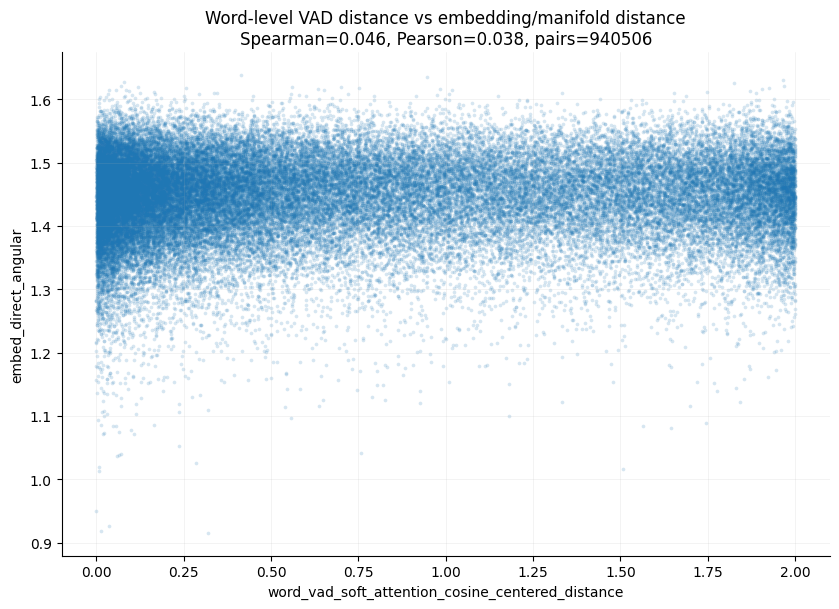

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\best_word_vad_vs_manifold_scatter.png
Best truth: word_vad_soft_attention_cosine_centered_distance
Best representation: embed_direct_angular


In [25]:
best = results.iloc[0]
best_truth_name = best["truth_distance"]
best_rep_name = best["representation_distance"]

truth_upper = upper_values(truth_matrices[best_truth_name])
rep_upper = upper_values(distance_matrices[best_rep_name])

mask = np.isfinite(truth_upper) & np.isfinite(rep_upper)
truth_clean = truth_upper[mask]
rep_clean = rep_upper[mask]

n = len(truth_clean)
if n > MAX_SCATTER_PAIRS:
    plot_idx = rng.choice(n, size=MAX_SCATTER_PAIRS, replace=False)
else:
    plot_idx = np.arange(n)

fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.scatter(truth_clean[plot_idx], rep_clean[plot_idx], s=7, alpha=0.18, linewidths=0)
ax.set_xlabel(best_truth_name)
ax.set_ylabel(best_rep_name)
ax.set_title(
    "Word-level VAD distance vs embedding/manifold distance\n"
    f"Spearman={best['spearman_rho']:.3f}, Pearson={best['pearson_r']:.3f}, pairs={int(best['n_pairs'])}"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linewidth=0.4, alpha=0.25)
fig.tight_layout()

plot_path = OUT_DIR / "best_word_vad_vs_manifold_scatter.png"
fig.savefig(plot_path, dpi=220)
plt.show()

print("Saved:", plot_path)
print("Best truth:", best_truth_name)
print("Best representation:", best_rep_name)

## 10. Coverage plot

This is boring but important. If your VAD coverage is terrible, the ground truth is not really “improved”; it is just a spreadsheet wearing a lab coat.

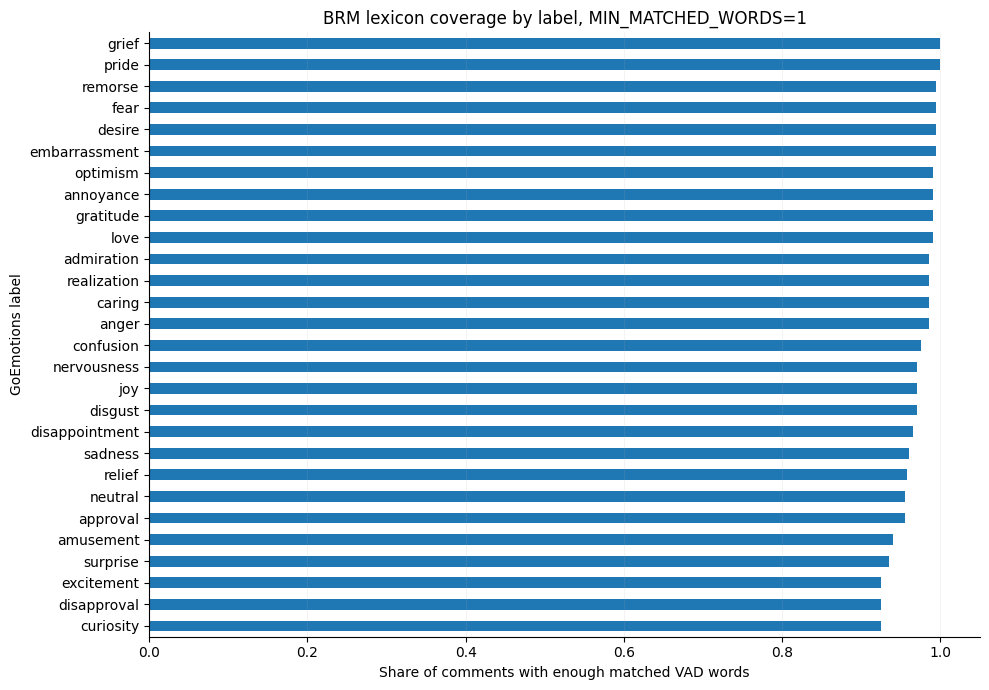

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\word_vad_coverage_by_label.csv
Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\word_vad_coverage_by_label.png


,label_name,total,usable,mean_coverage,median_vad_words,usable_rate
7,curiosity,201,186,0.290721,4.0,0.925373
10,disapproval,201,186,0.290408,4.0,0.925373
13,excitement,201,186,0.365343,3.0,0.925373
27,surprise,201,188,0.294655,3.0,0.935323
1,amusement,201,189,0.283721,3.0,0.940299
4,approval,201,192,0.307865,4.0,0.955224
20,neutral,201,192,0.322357,4.0,0.955224
24,relief,71,68,0.305195,3.0,0.957746
26,sadness,201,193,0.306565,4.0,0.960199
9,disappointment,201,194,0.296283,4.0,0.965174


In [26]:
coverage_by_label = (
    comment_vad.groupby("label_name")
    .agg(
        total=("label_name", "size"),
        usable=("has_word_vad", "sum"),
        mean_coverage=("coverage", "mean"),
        median_vad_words=("n_vad_words", "median"),
    )
    .reset_index()
)
coverage_by_label["usable_rate"] = coverage_by_label["usable"] / coverage_by_label["total"]

coverage_path = OUT_DIR / "word_vad_coverage_by_label.csv"
coverage_by_label.to_csv(coverage_path, index=False)

fig, ax = plt.subplots(figsize=(10, 7))
coverage_by_label.sort_values("usable_rate").plot.barh(
    x="label_name",
    y="usable_rate",
    ax=ax,
    legend=False,
)
ax.set_xlabel("Share of comments with enough matched VAD words")
ax.set_ylabel("GoEmotions label")
ax.set_title(f"BRM lexicon coverage by label, MIN_MATCHED_WORDS={MIN_MATCHED_WORDS}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="x", linewidth=0.4, alpha=0.25)
fig.tight_layout()

coverage_plot_path = OUT_DIR / "word_vad_coverage_by_label.png"
fig.savefig(coverage_plot_path, dpi=220)
plt.show()

print("Saved:", coverage_path)
print("Saved:", coverage_plot_path)
display(coverage_by_label.sort_values("usable_rate"))

## 11. Optional: compare within-label vs across-label distances

This is a sanity check. If word-VAD distances do not behave differently within versus across labels, the word averaging may be too noisy.

In [27]:
iu = pair_index(len(sampled))
same_label = sampled["label_name"].to_numpy()[iu[0]] == sampled["label_name"].to_numpy()[iu[1]]

diagnostic_rows = []
for truth_name, truth_D in truth_matrices.items():
    v = upper_values(truth_D)
    diagnostic_rows.append({
        "distance": truth_name,
        "within_label_mean": float(np.nanmean(v[same_label])),
        "across_label_mean": float(np.nanmean(v[~same_label])),
        "within_label_median": float(np.nanmedian(v[same_label])),
        "across_label_median": float(np.nanmedian(v[~same_label])),
    })

for rep_name, rep_D in distance_matrices.items():
    v = upper_values(rep_D)
    diagnostic_rows.append({
        "distance": rep_name,
        "within_label_mean": float(np.nanmean(v[same_label])),
        "across_label_mean": float(np.nanmean(v[~same_label])),
        "within_label_median": float(np.nanmedian(v[same_label])),
        "across_label_median": float(np.nanmedian(v[~same_label])),
    })

diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics_path = OUT_DIR / "within_across_label_distance_diagnostics.csv"
diagnostics.to_csv(diagnostics_path, index=False)

print("Saved:", diagnostics_path)
display(diagnostics)

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\within_across_label_distance_diagnostics.csv


,distance,within_label_mean,across_label_mean,within_label_median,across_label_median
0,word_vad_euclidean,1.370112,1.576563,1.175426,1.351028
1,word_vad_cosine_raw_distance,0.009160,0.011313,0.003590,0.004606
2,word_vad_cosine_centered_distance,0.407359,0.489798,0.183226,0.250528
3,word_vad_soft_attention_euclidean,1.862025,2.189447,1.640793,1.961476
4,word_vad_soft_attention_cosine_centered_distance,0.585031,0.733232,0.335536,0.512520
5,embed_direct_cosine,0.833172,0.876909,0.843885,0.882655
6,embed_direct_angular,1.402480,1.447110,1.414040,1.453180
7,embed_knn_geodesic_angular_pca_50_k2,8.047367,8.689678,8.536634,8.882798


## Notes for interpreting the output

- A higher positive Spearman correlation means the embedding/manifold geometry ranks comment pairs more similarly to the word-VAD ground-truth geometry.
- Do not over-worship raw cosine VAD. On a 1-9 scale it can be dominated by positivity and vector length issues.
- If `word_vad_cosine_centered_distance` beats raw cosine, that is not surprising.
- If coverage is low or varies heavily by label, report it. Otherwise the “ground truth” is biased toward comments with lexicon-friendly vocabulary.
- This is a baseline, not a final truth oracle. Language is messy, and spreadsheets are just rectangles with confidence problems.

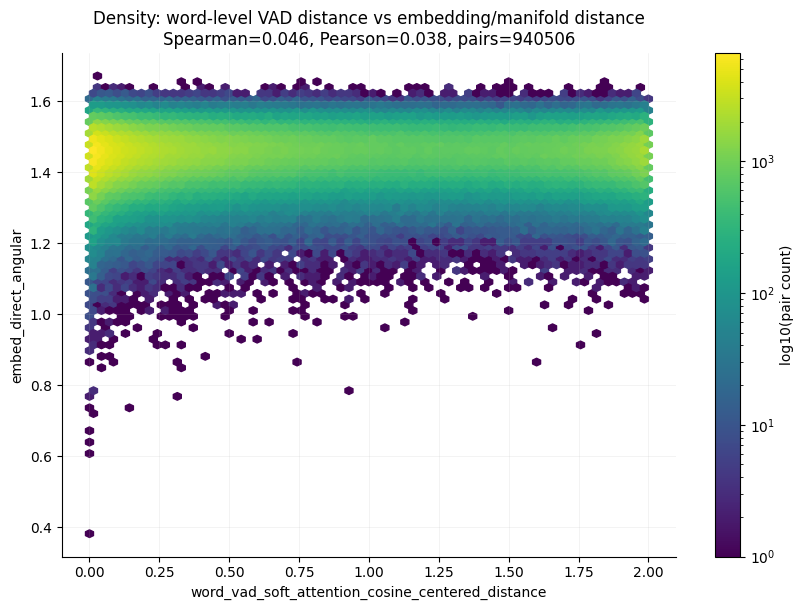

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\density_word_vad_soft_attention_cosine_centered_distance_vs_embed_direct_angular.png


In [28]:
best = results.iloc[0]
best_truth_name = best["truth_distance"]
best_rep_name = best["representation_distance"]

truth_upper = upper_values(truth_matrices[best_truth_name])
rep_upper = upper_values(distance_matrices[best_rep_name])

mask = np.isfinite(truth_upper) & np.isfinite(rep_upper)
truth_clean = truth_upper[mask]
rep_clean = rep_upper[mask]

fig, ax = plt.subplots(figsize=(8.5, 6.2))

hb = ax.hexbin(
    truth_clean,
    rep_clean,
    gridsize=70,
    bins="log",
    mincnt=1,
)

fig.colorbar(hb, ax=ax, label="log10(pair count)")

ax.set_xlabel(best_truth_name)
ax.set_ylabel(best_rep_name)
ax.set_title(
    "Density: word-level VAD distance vs embedding/manifold distance\n"
    f"Spearman={best['spearman_rho']:.3f}, Pearson={best['pearson_r']:.3f}, pairs={int(best['n_pairs'])}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linewidth=0.4, alpha=0.25)

fig.tight_layout()

density_plot_path = OUT_DIR / f"density_{best_truth_name}_vs_{best_rep_name}.png"
fig.savefig(density_plot_path, dpi=220)
plt.show()

print("Saved:", density_plot_path)

In [29]:
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Centroid-level comparison:
# Average embeddings and word-derived VAD per GoEmotions label.
# ------------------------------------------------------------

centroid_rows = []
X_centroids = []
V_centroids = []

for label_name, group in sampled.groupby("label_name", sort=True):
    idx = group.index.to_numpy()

    X_centroids.append(X_sample[idx].mean(axis=0))
    V_centroids.append(V_sample_attention[idx].mean(axis=0))

    centroid_rows.append({
        "label_name": label_name,
        "n_comments": len(group),
        "word_vad_valence": V_sample_attention[idx, 0].mean(),
        "word_vad_arousal": V_sample_attention[idx, 1].mean(),
        "word_vad_dominance": V_sample_attention[idx, 2].mean(),
    })

centroid_df = pd.DataFrame(centroid_rows)
X_centroids = np.vstack(X_centroids)
V_centroids = np.vstack(V_centroids)

print("Centroids:", X_centroids.shape, V_centroids.shape)
display(centroid_df)

# Embedding distances
D_embed_cosine = pairwise_distances(X_centroids, metric="cosine")
D_embed_angular = np.arccos(np.clip(1 - D_embed_cosine, -1, 1))

# Word VAD distances
D_word_vad_euclidean = pairwise_distances(V_centroids, metric="euclidean")
D_word_vad_centered_cosine = pairwise_distances(V_centroids - 5.0, metric="cosine")

def upper_values(D):
    iu = np.triu_indices(D.shape[0], k=1)
    return D[iu]

centroid_results = []

for vad_name, D_vad in {
    "centroid_word_vad_euclidean": D_word_vad_euclidean,
    "centroid_word_vad_centered_cosine": D_word_vad_centered_cosine,
}.items():
    for emb_name, D_emb in {
        "centroid_embedding_cosine": D_embed_cosine,
        "centroid_embedding_angular": D_embed_angular,
    }.items():
        a = upper_values(D_vad)
        b = upper_values(D_emb)
        mask = np.isfinite(a) & np.isfinite(b)

        sr = spearmanr(a[mask], b[mask])
        pr = pearsonr(a[mask], b[mask])

        centroid_results.append({
            "vad_distance": vad_name,
            "embedding_distance": emb_name,
            "spearman_rho": sr.statistic,
            "spearman_p": sr.pvalue,
            "pearson_r": pr.statistic,
            "pearson_p": pr.pvalue,
            "n_pairs": mask.sum(),
        })

centroid_results = pd.DataFrame(centroid_results).sort_values(
    "spearman_rho",
    key=lambda s: s.abs(),
    ascending=False,
)

display(centroid_results)

centroid_results_path = OUT_DIR / "centroid_word_vad_embedding_alignment.csv"
centroid_results.to_csv(centroid_results_path, index=False)
print("Saved:", centroid_results_path)

Centroids: (28, 3072) (28, 3)


,label_name,n_comments,word_vad_valence,word_vad_arousal,word_vad_dominance
0,admiration,50,6.736225,4.335677,6.100693
1,amusement,50,5.948177,4.711563,5.696460
2,anger,50,4.590676,4.892207,5.074550
3,annoyance,50,5.202298,4.423126,5.280131
4,approval,50,5.686768,4.217762,5.812004
5,caring,50,6.032411,4.243617,5.715474
6,confusion,50,4.947486,4.106511,5.378094
7,curiosity,50,5.658720,4.369248,5.551792
8,desire,50,6.171307,4.126559,5.859436
9,disappointment,50,5.060324,4.397242,5.342976


,vad_distance,embedding_distance,spearman_rho,spearman_p,pearson_r,pearson_p,n_pairs
0,centroid_word_vad_euclidean,centroid_embedding_cosine,0.531206,6.558656e-29,0.539109,6.962430e-30,378
1,centroid_word_vad_euclidean,centroid_embedding_angular,0.531206,6.558656e-29,0.536445,1.492840e-29,378
2,centroid_word_vad_centered_cosine,centroid_embedding_cosine,0.355622,1.037547e-12,0.320127,1.867928e-10,378
3,centroid_word_vad_centered_cosine,centroid_embedding_angular,0.355622,1.037547e-12,0.317320,2.739126e-10,378


Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\centroid_word_vad_embedding_alignment.csv


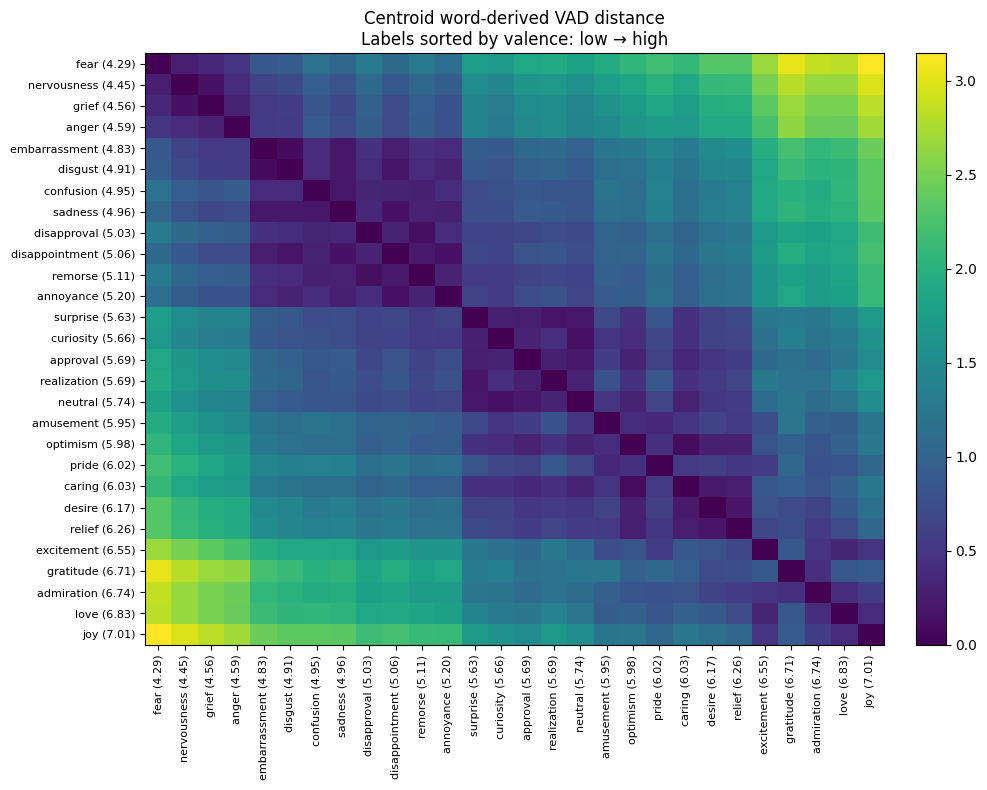

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\heatmap_centroid_word_vad_distance_ranked_by_valence.png


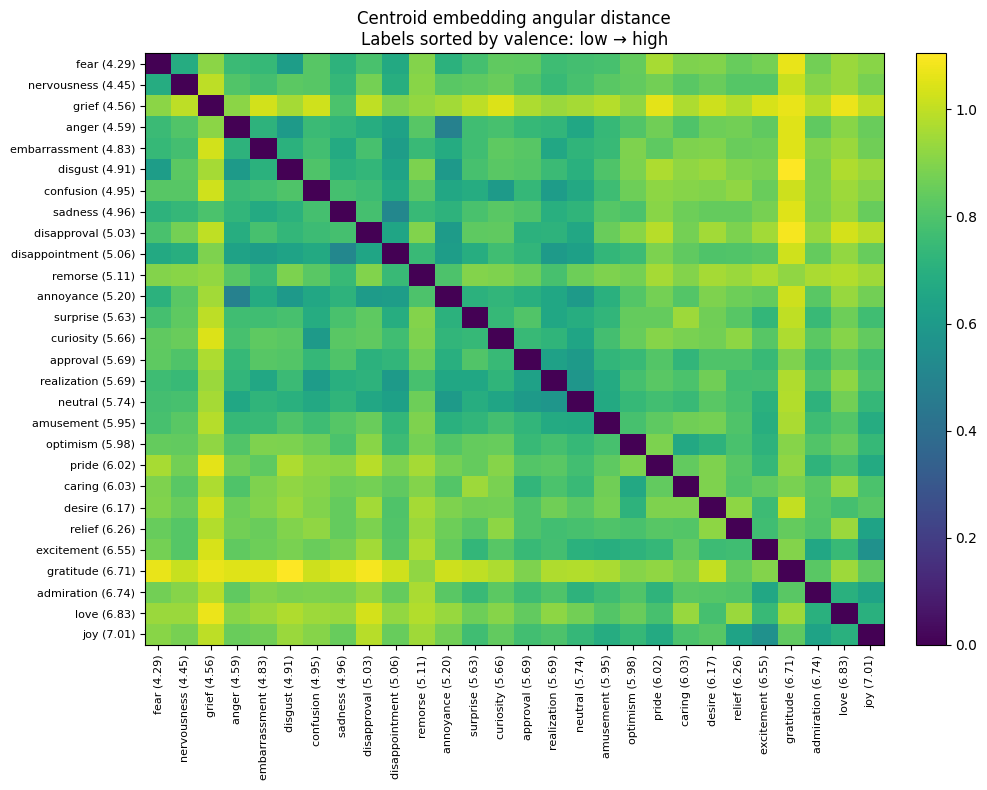

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\heatmap_centroid_embedding_angular_distance_ranked_by_valence.png


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_distance_heatmap_ranked_by_valence(
    D,
    centroid_df,
    title,
    out_path,
    valence_col="word_vad_valence",
):
    # Sort labels from low valence to high valence
    order = np.argsort(centroid_df[valence_col].to_numpy())

    D_sorted = D[np.ix_(order, order)]
    label_names_sorted = centroid_df["label_name"].astype(str).to_numpy()[order]
    valence_sorted = centroid_df[valence_col].to_numpy()[order]

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(D_sorted, aspect="auto")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_labels = [
        f"{lab} ({val:.2f})"
        for lab, val in zip(label_names_sorted, valence_sorted)
    ]

    ax.set_xticks(np.arange(len(label_names_sorted)))
    ax.set_yticks(np.arange(len(label_names_sorted)))
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)

    ax.set_title(title + "\nLabels sorted by valence: low → high")

    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.show()

    print("Saved:", out_path)


plot_distance_heatmap_ranked_by_valence(
    D_word_vad_euclidean,
    centroid_df,
    "Centroid word-derived VAD distance",
    OUT_DIR / "heatmap_centroid_word_vad_distance_ranked_by_valence.png",
)

plot_distance_heatmap_ranked_by_valence(
    D_embed_angular,
    centroid_df,
    "Centroid embedding angular distance",
    OUT_DIR / "heatmap_centroid_embedding_angular_distance_ranked_by_valence.png",
)

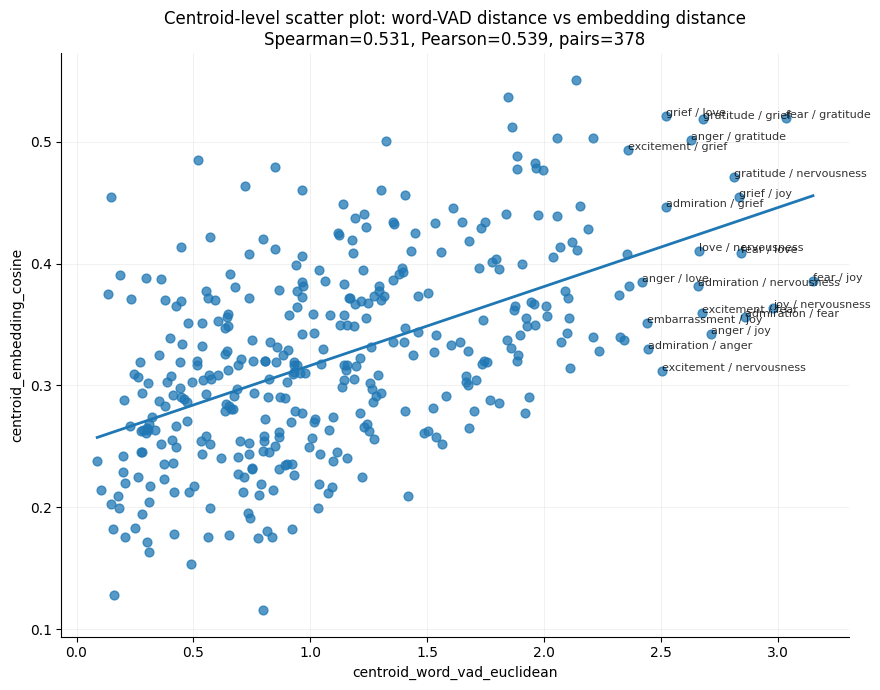

Saved: D:\pyprojects\m4r\new_plots\word_vad_ground_truth\centroid_word_vad_vs_embedding_scatter.png


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure these exist from the centroid-analysis cell:
# centroid_df
# centroid_results
# D_word_vad_euclidean
# D_word_vad_centered_cosine
# D_embed_cosine
# D_embed_angular
# OUT_DIR

label_names = centroid_df["label_name"].astype(str).tolist()

best = centroid_results.iloc[0]

D_vad_lookup = {
    "centroid_word_vad_euclidean": D_word_vad_euclidean,
    "centroid_word_vad_centered_cosine": D_word_vad_centered_cosine,
}

D_emb_lookup = {
    "centroid_embedding_cosine": D_embed_cosine,
    "centroid_embedding_angular": D_embed_angular,
}

D_vad = D_vad_lookup[best["vad_distance"]]
D_emb = D_emb_lookup[best["embedding_distance"]]

xs = []
ys = []
pair_labels = []

for i in range(len(label_names)):
    for j in range(i + 1, len(label_names)):
        xs.append(D_vad[i, j])
        ys.append(D_emb[i, j])
        pair_labels.append(f"{label_names[i]} / {label_names[j]}")

xs = np.array(xs)
ys = np.array(ys)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(xs, ys, s=40, alpha=0.75)

# Optional: add a simple least-squares line
if len(xs) >= 2:
    m, b = np.polyfit(xs, ys, 1)
    xline = np.linspace(xs.min(), xs.max(), 200)
    yline = m * xline + b
    ax.plot(xline, yline, linewidth=2)

# Label only a subset so the plot stays readable
# Here: top 20 most distant pairs by combined distance
top_idx = np.argsort(xs + ys)[-20:]

for idx in top_idx:
    ax.text(
        xs[idx],
        ys[idx],
        pair_labels[idx],
        fontsize=8,
        alpha=0.8,
    )

ax.set_xlabel(best["vad_distance"])
ax.set_ylabel(best["embedding_distance"])
ax.set_title(
    "Centroid-level scatter plot: word-VAD distance vs embedding distance\n"
    f"Spearman={best['spearman_rho']:.3f}, Pearson={best['pearson_r']:.3f}, pairs={int(best['n_pairs'])}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linewidth=0.4, alpha=0.3)

fig.tight_layout()

scatter_path = OUT_DIR / "centroid_word_vad_vs_embedding_scatter.png"
fig.savefig(scatter_path, dpi=220)
plt.show()

print("Saved:", scatter_path)